<a href="https://colab.research.google.com/github/ShAnFb82/IAD1/blob/main/IADlab1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Обраний датасет - Android malware detection (Drebin)
https://www.kaggle.com/datasets/subhajournal/android-malware-detection/data

Цей набір містить дані про 15 036 додатків. З них 9476 - це цілком безпечні програми, а 5560 - це шкідливе програмне забезпечення.


In [15]:
Крок 1: Завантаження та первинний аналіз даних

SyntaxError: invalid syntax (1453542088.py, line 1)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Завантажуємо датасет
df = pd.read_csv('drebin-215-dataset-5560malware-9476-benign.csv')

# Виводимо розмір датасета (кількість рядків та колонок)
print("Розмір датасета:", df.shape)

# Виводимо перші 5 рядків, щоб подивитися на дані
display(df.head())

# Дивимось, скільки у нас шкідливих і безпечних додатків
# У датасеті Drebin цільова колонка зазвичай називається 'class'
print("\nРозподіл за класами:")
print(df['class'].value_counts())

Розмір датасета: (15036, 216)


/tmp/ipykernel_1913/1174494011.py:7: DtypeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('drebin-215-dataset-5560malware-9476-benign.csv')


,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S



Розподіл за класами:
class
B    9476
S    5560
Name: count, dtype: int64


In [ ]:
Крок 2: Попередня обробка даних (Preprocessing)

In [5]:
# 1. Кодування цільової змінної 'class' (категоріальна ознака)
# 'B' (Benign - безпечні) стає 0, 'S' (Malware - шкідливі) стає 1
df['class'] = df['class'].map({'B': 0, 'S': 1})

# 2. Виправлення типів даних та проблеми з 92-ю колонкою
# Примусово перетворюємо весь датасет у числа.
# Параметр errors='coerce' перетворить будь-яке текстове сміття у порожні значення (NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# 3. Перевірка на наявність пропущених значень (NaN)
missing_values = df.isnull().sum().sum()
print(f"Кількість пропусків ДО обробки: {missing_values}")

if missing_values > 0:
    # Оскільки всі наші ознаки - це наявність або відсутність дозволів/API-викликів,
    # найбільш логічно заповнити невідомі значення нулями (тобто "дозволу немає")
    df = df.fillna(0)
    print("Всі пропуски успішно заповнено нулями.")

# 4. Визначаємо ознаки (X) та цільову змінну (y)
X = df.drop('class', axis=1) # Всі колонки, крім 'class'
y = df['class']              # Тільки колонка 'class'

print("\nРозмір матриці ознак (X):", X.shape)
print("Новий розподіл класів (0 - безпечні, 1 - шкідливі):")
print(y.value_counts())

Кількість пропусків ДО обробки: 5
Всі пропуски успішно заповнено нулями.

Розмір матриці ознак (X): (15036, 215)
Новий розподіл класів (0 - безпечні, 1 - шкідливі):
class
0    9476
1    5560
Name: count, dtype: int64


In [ ]:
Крок 3 : Візуалізація та дослідження даних (EDA).

Топ-10 найважливіших ознак:
 ['SEND_SMS', 'android.telephony.SmsManager', 'READ_PHONE_STATE', 'RECEIVE_SMS', 'READ_SMS', 'android.intent.action.BOOT_COMPLETED', 'TelephonyManager.getLine1Number', 'WRITE_SMS', 'WRITE_HISTORY_BOOKMARKS', 'TelephonyManager.getSubscriberId']


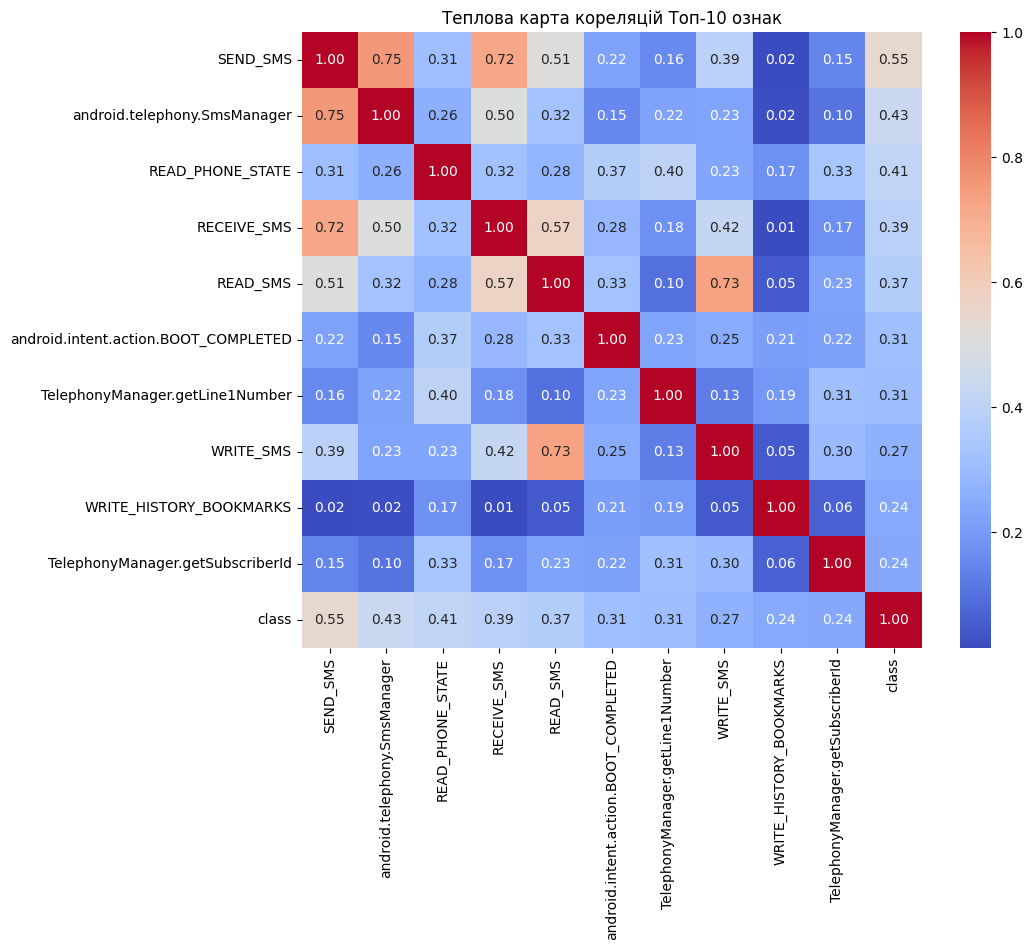

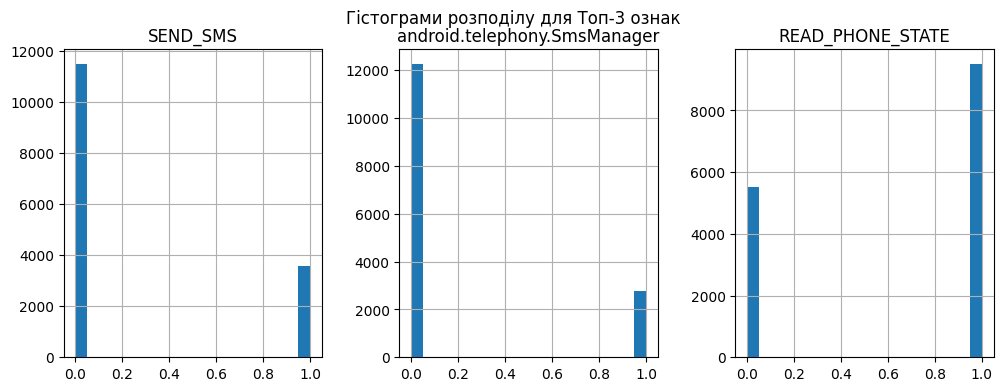

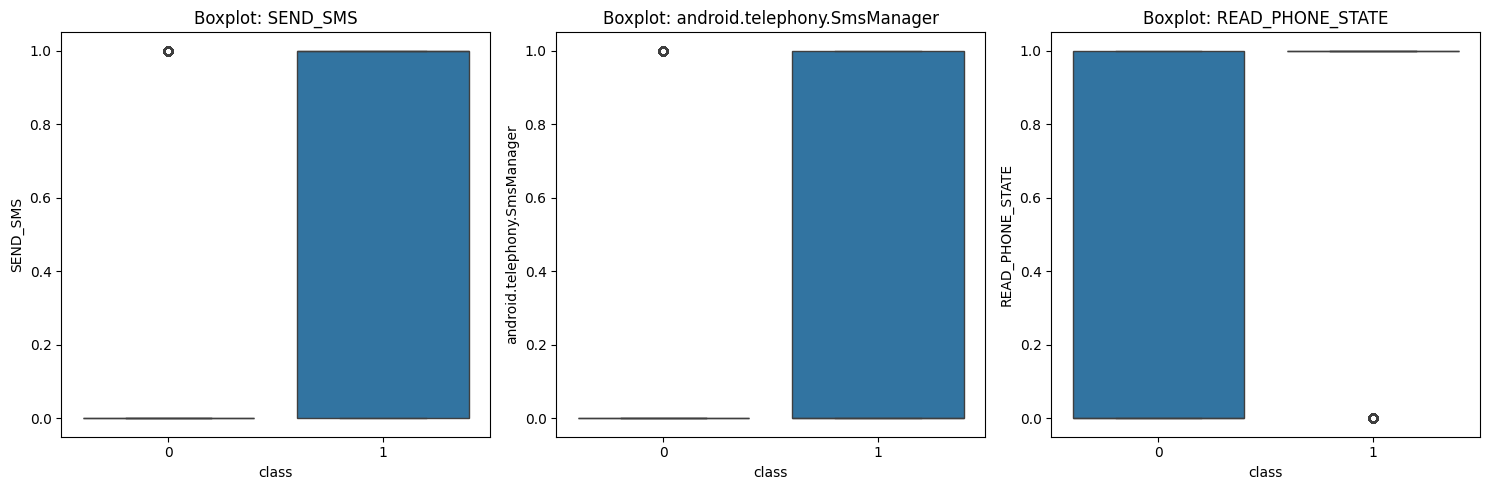

In [6]:
# Знаходимо кореляцію всіх ознак з цільовою змінною 'class'
correlations = df.corr()['class'].sort_values(ascending=False)

# Беремо топ-10 ознак (без самої колонки 'class')
top_features = correlations[1:11].index.tolist()
print("Топ-10 найважливіших ознак:\n", top_features)

# 1. Heatmap (Теплова карта кореляцій)
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features + ['class']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Теплова карта кореляцій Топ-10 ознак')
plt.show()

# 2. Гістограми розподілу для топ-3 ознак
df[top_features[:3]].hist(bins=20, figsize=(12, 4), layout=(1, 3))
plt.suptitle('Гістограми розподілу для Топ-3 ознак')
plt.show()

# 3. Boxplot-и (Ящики з вусами) для топ-3 ознак відносно класу
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feature in enumerate(top_features[:3]):
    sns.boxplot(x='class', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Boxplot: {feature}')
plt.tight_layout()
plt.show()

In [ ]:
Крок 4: Підготовка даних до навчання

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Розділення даних на тренувальну (80%) та тестову (20%) вибірки
# stratify=y гарантує, що пропорція шкідливих і безпечних програм збережеться рівномірно
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Розмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

# 2. Масштабування (нормалізація) ознак
scaler = StandardScaler()

# Навчаємо scaler на тренувальних даних і одразу трансформуємо їх
X_train_scaled = scaler.fit_transform(X_train)

# Тестові дані ТІЛЬКИ трансформуємо (щоб алгоритм їх "не бачив" заздалегідь)
X_test_scaled = scaler.transform(X_test)

print("Дані успішно розділено та відмасштабовано!")

Розмір тренувальної вибірки: (12028, 215)
Розмір тестової вибірки: (3008, 215)
Дані успішно розділено та відмасштабовано!


In [11]:
 Крок 5 (6) Підбір гіперпараметрів

SyntaxError: invalid syntax (4192416334.py, line 1)

In [13]:
# Підбір гіперпараметрів для kNN та SVM
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

print("Починаємо підбір параметрів для kNN...")
knn_params = {'n_neighbors': [3, 5, 7, 9]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
print(f"Найкращі параметри kNN: {knn_grid.best_params_}")

print("\nПочинаємо підбір параметрів для SVM (це займе кілька хвилин)...")
svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale']}
svm_grid = GridSearchCV(SVC(), svm_params, cv=3, n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
print(f"Найкращі параметри SVM: {svm_grid.best_params_}")

Починаємо підбір параметрів для kNN...
Найкращі параметри kNN: {'n_neighbors': 3}

Починаємо підбір параметрів для SVM (це займе кілька хвилин)...
Найкращі параметри SVM: {'C': 10, 'gamma': 'scale'}


In [ ]:
Крок 6 (5) Ініціалізація моделей

In [12]:
# Ініціалізація всіх моделей
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Завантажуємо найкращі версії kNN та SVM з попереднього кроку,
# а також додаємо базові версії інших алгоритмів
models = {
    "k-Nearest Neighbors": knn_grid.best_estimator_,
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine": svm_grid.best_estimator_,
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}
print("Всі 5 класифікаторів успішно ініціалізовано!")

Всі 5 класифікаторів успішно ініціалізовано!


In [ ]:
Крок 7 Навчання, оцінювання та візуалізація


Навчання та оцінка моделі: k-Nearest Neighbors
Час виконання: 1.40 секунд

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.98      0.98      0.98      1112

    accuracy                           0.98      3008
   macro avg       0.98      0.98      0.98      3008
weighted avg       0.98      0.98      0.98      3008



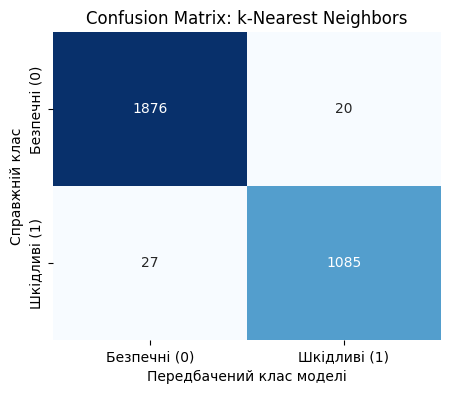


Навчання та оцінка моделі: Decision Tree
Час виконання: 0.38 секунд

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1896
           1       0.97      0.97      0.97      1112

    accuracy                           0.98      3008
   macro avg       0.98      0.98      0.98      3008
weighted avg       0.98      0.98      0.98      3008



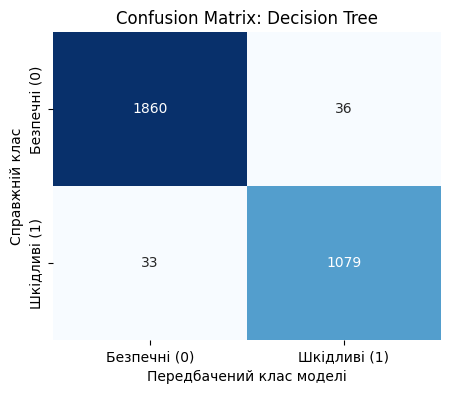


Навчання та оцінка моделі: Support Vector Machine
Час виконання: 5.07 секунд

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.98      0.98      1112

    accuracy                           0.99      3008
   macro avg       0.99      0.99      0.99      3008
weighted avg       0.99      0.99      0.99      3008



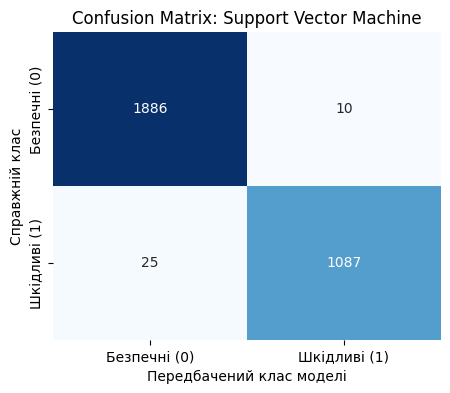


Навчання та оцінка моделі: Random Forest
Час виконання: 1.81 секунд

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.98      0.98      1112

    accuracy                           0.99      3008
   macro avg       0.99      0.99      0.99      3008
weighted avg       0.99      0.99      0.99      3008



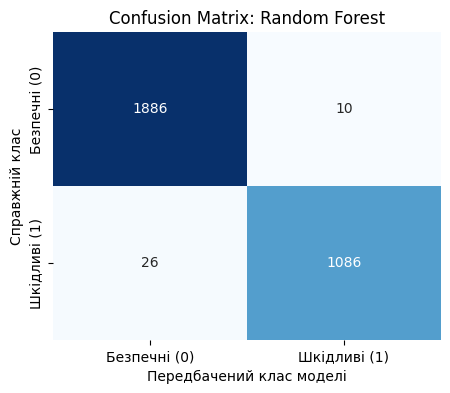


Навчання та оцінка моделі: AdaBoost
Час виконання: 3.55 секунд

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1896
           1       0.93      0.93      0.93      1112

    accuracy                           0.95      3008
   macro avg       0.94      0.94      0.94      3008
weighted avg       0.95      0.95      0.95      3008



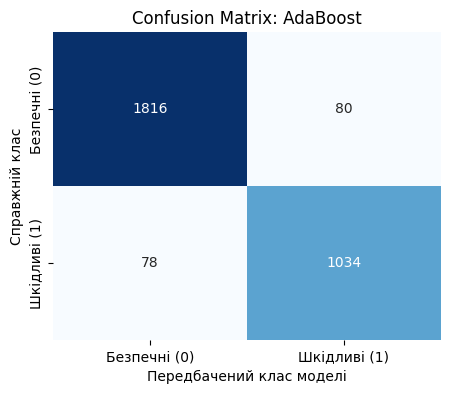

In [14]:
# Крок 7. Навчання, порівняння та оцінювання моделей
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

for name, model in models.items():
    print(f"\n{'='*50}\nНавчання та оцінка моделі: {name}")
    start_time = time.time()

    # Навчання моделі
    model.fit(X_train_scaled, y_train)

    # Прогнозування на тестовій вибірці
    y_pred = model.predict(X_test_scaled)

    print(f"Час виконання: {time.time() - start_time:.2f} секунд")

    # Виведення результатів
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Візуалізація Confusion Matrix у вигляді кольорових квадратів
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Безпечні (0)', 'Шкідливі (1)'],
                yticklabels=['Безпечні (0)', 'Шкідливі (1)'])

    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Передбачений клас моделі')
    plt.ylabel('Справжній клас')
    plt.show()

In [ ]:
Висновки:
Support Vector Machine (SVM) та Random Forest стали абсолютними лідерами, показавши точність (accuracy) 99%. Вони майже ідеально розділили класи.

Якщо придивитися до деталей, SVM помилився лише на 1 додаток менше, ніж Random Forest: SVM пропустив 25 вірусів, а Random Forest — 26. Кількість хибних тривог у них однакова — по 10

Проте, Random Forest відпрацював значно швидше (1.81 секунди проти 5.07 секунд у SVM).

In [ ]:
(Для оптимізації кроки 5-7 разом)

Починаємо підбір параметрів для kNN...
Найкращі параметри kNN: {'n_neighbors': 3}

Починаємо підбір параметрів для SVM (це займе кілька хвилин)...
Найкращі параметри SVM: {'C': 10, 'gamma': 'scale'}

Навчання та оцінка моделі: k-Nearest Neighbors
Час виконання: 0.78 секунд

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.98      0.98      0.98      1112

    accuracy                           0.98      3008
   macro avg       0.98      0.98      0.98      3008
weighted avg       0.98      0.98      0.98      3008



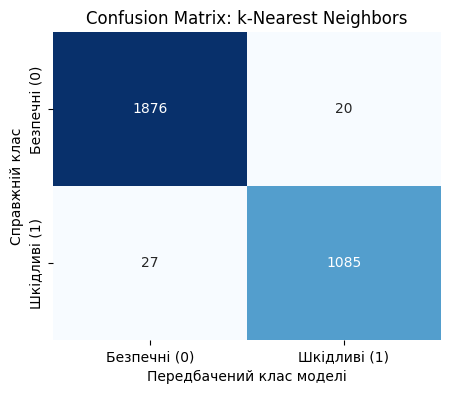


Навчання та оцінка моделі: Decision Tree
Час виконання: 0.24 секунд

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1896
           1       0.97      0.97      0.97      1112

    accuracy                           0.98      3008
   macro avg       0.98      0.98      0.98      3008
weighted avg       0.98      0.98      0.98      3008



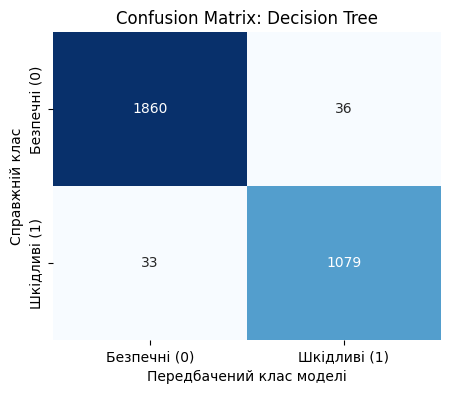


Навчання та оцінка моделі: Support Vector Machine
Час виконання: 6.07 секунд

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.98      0.98      1112

    accuracy                           0.99      3008
   macro avg       0.99      0.99      0.99      3008
weighted avg       0.99      0.99      0.99      3008



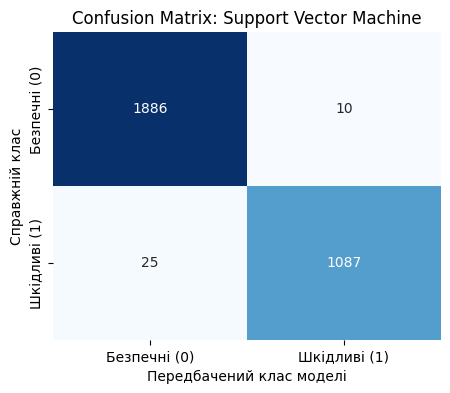


Навчання та оцінка моделі: Random Forest
Час виконання: 1.69 секунд

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.98      0.98      1112

    accuracy                           0.99      3008
   macro avg       0.99      0.99      0.99      3008
weighted avg       0.99      0.99      0.99      3008



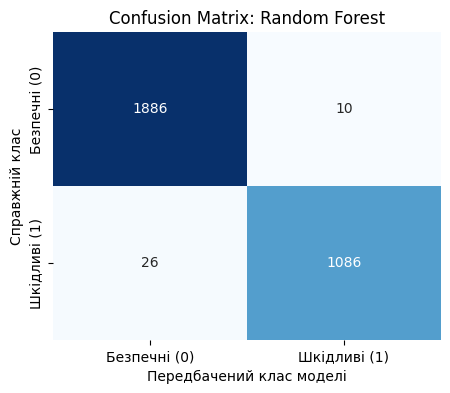


Навчання та оцінка моделі: AdaBoost
Час виконання: 1.51 секунд

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1896
           1       0.93      0.93      0.93      1112

    accuracy                           0.95      3008
   macro avg       0.94      0.94      0.94      3008
weighted avg       0.95      0.95      0.95      3008



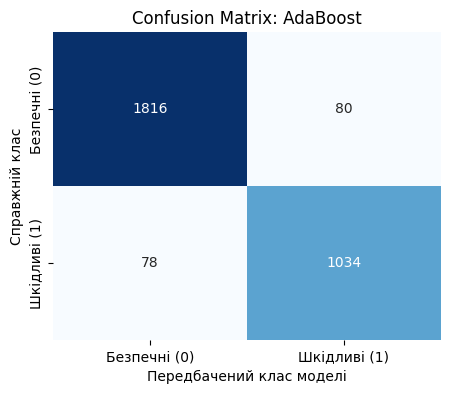

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import time

# 1. Підбір гіперпараметрів для kNN та SVM (Крок 6)
print("Починаємо підбір параметрів для kNN...")
knn_params = {'n_neighbors': [3, 5, 7, 9]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
print(f"Найкращі параметри kNN: {knn_grid.best_params_}")

print("\nПочинаємо підбір параметрів для SVM (це займе кілька хвилин)...")
# Використовуємо компактну сітку параметрів, щоб уникнути зависання Colab
svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale']}
svm_grid = GridSearchCV(SVC(), svm_params, cv=3, n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
print(f"Найкращі параметри SVM: {svm_grid.best_params_}")

# 2. Ініціалізація всіх моделей з найкращими параметрами (Крок 5)
models = {
    "k-Nearest Neighbors": knn_grid.best_estimator_,
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine": svm_grid.best_estimator_,
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}
# 3. Навчання, оцінювання та візуалізація кожної моделі (Крок 7)
for name, model in models.items():
    print(f"\n{'='*50}\nНавчання та оцінка моделі: {name}")
    start_time = time.time()

    # Навчання моделі
    model.fit(X_train_scaled, y_train)

    # Прогнозування на тестовій вибірці
    y_pred = model.predict(X_test_scaled)

    print(f"Час виконання: {time.time() - start_time:.2f} секунд")

    # Виведення результатів
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Візуалізація Confusion Matrix у вигляді кольорових квадратів
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))

    # Малюємо теплову карту (cmap='Blues' задає синю кольорову гаму)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Безпечні (0)', 'Шкідливі (1)'],
                yticklabels=['Безпечні (0)', 'Шкідливі (1)'])

    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Передбачений клас моделі')
    plt.ylabel('Справжній клас')
    plt.show()